## Actividad 3_14
<div style="border-style:groove;border-width:thin;padding:10px">
Debes hacer lo siguiente:
    <ol>
        <li>Soluciona MNIST usando KMeans. Usa X_train y deja X_test e y_test guardados. Recuerda, no tienes que usar las etiquetas para nada.</li>
        <li>Muestra primeras imágenes de la clase 0, 1, 2, 3, 4, etc. ¿Qué tal lo ha hecho?</li>
        <li>Los centroides son datos de 784 valores. Pinta los 10 centroides como si fueran imágenes.</li>
        <li>Piensa como sacar una métrica del resultado.</li>
    </ol>
</div>

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


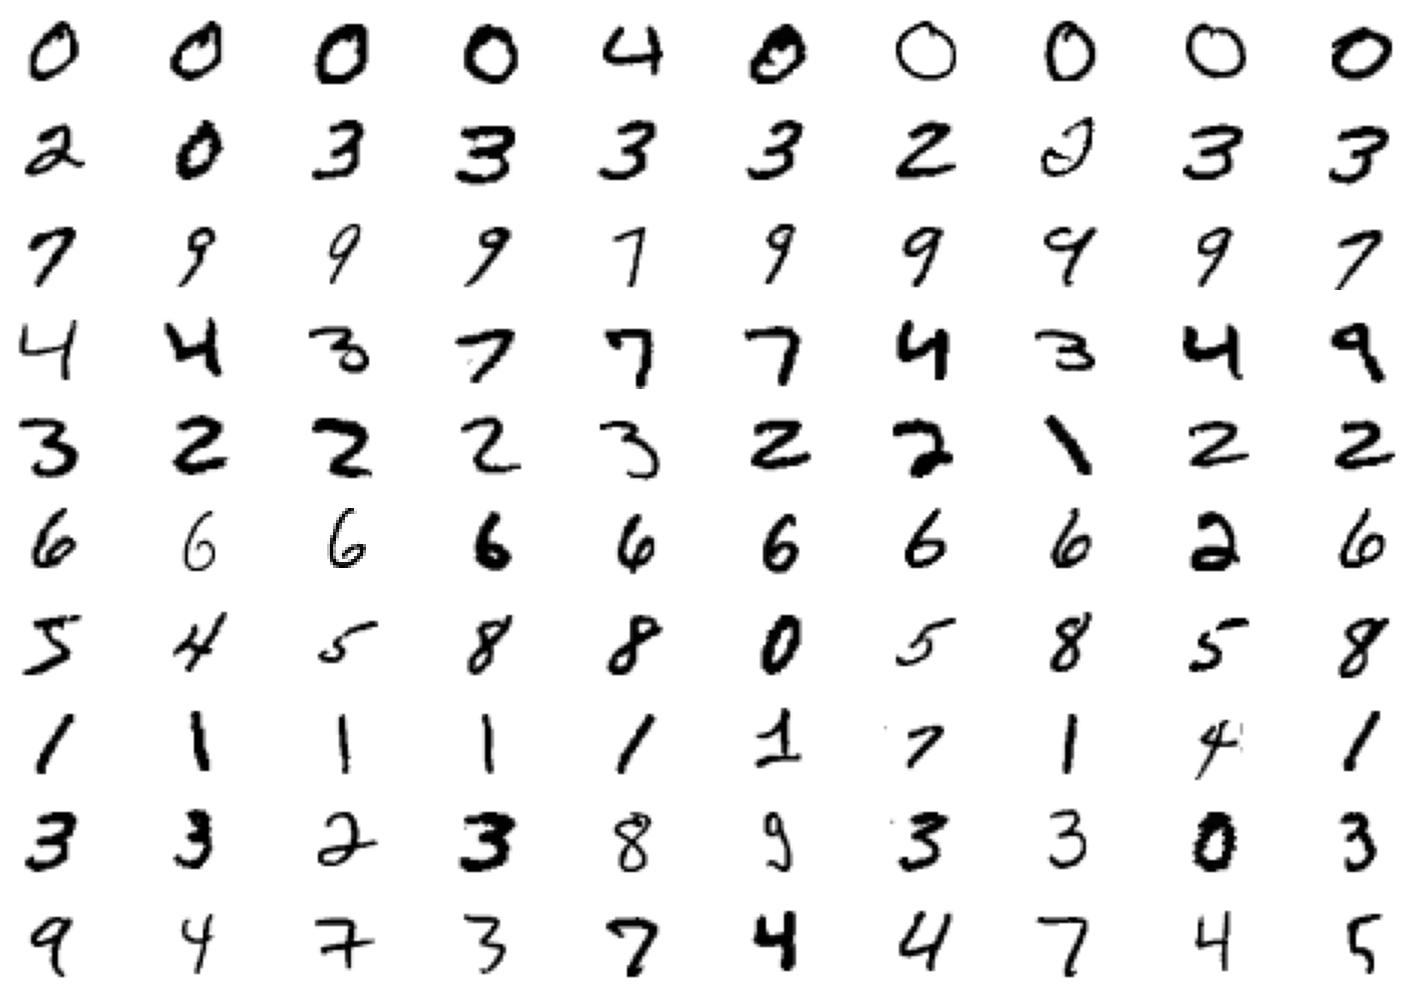

In [16]:
# Definimos cuántas imágenes queremos ver por cada uno de los 10 clusters
n_imagenes_por_cluster = 10 

plt.figure(figsize=(15, 10))

for i in range(10):
    # Obtenemos los índices de todas las imágenes que pertenecen al cluster i
    indices_del_cluster = np.where(clusters == i)[0]
    
    # Tomamos las primeras 'n' imágenes de ese grupo
    for j in range(n_imagenes_por_cluster):
        plt.subplot(10, n_imagenes_por_cluster, i * n_imagenes_por_cluster + j + 1)
        
        # Extraemos la imagen (asegurándonos de que sea un array de 28x28)
        indice_imagen = indices_del_cluster[j]
        imagen = X.iloc[indice_imagen].values.reshape(28, 28)
        
        plt.imshow(imagen, cmap='binary')
        plt.axis('off')
        
        # Solo ponemos el título en la primera columna para identificar el cluster
        if j == 0:
            plt.ylabel(f"Cluster {i}", fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
# 1. Preprocesamiento: Escalar los datos 
# K-Means se basa en distancias euclidianas, por lo que el escalado es vital
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Configurar y entrenar el modelo K-Means
# Como sabemos que hay 10 dígitos (0 al 9), usaremos n_clusters=10
n_digits = 10
kmeans = KMeans(n_clusters=n_digits, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 3. Obtener las etiquetas de los clusters
clusters = kmeans.labels_

print(f"Forma de los centros de los clusters: {kmeans.cluster_centers_.shape}")

Forma de los centros de los clusters: (10, 784)


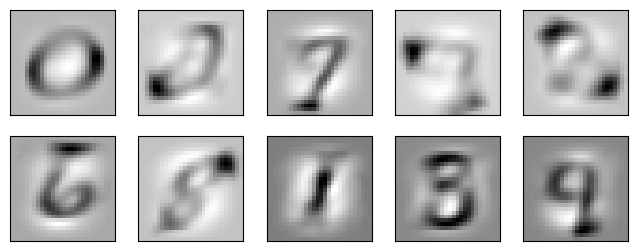

In [13]:
# Visualización de los centros de los clusters
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 28, 28)

for i, axi in enumerate(ax.flat):
    axi.set(xticks=[], yticks=[])
    # Invertimos el escalado solo para la visualización si es necesario, 
    # o mostramos el centroide directamente
    axi.imshow(centers[i], interpolation='nearest', cmap=plt.cm.binary)

plt.show()

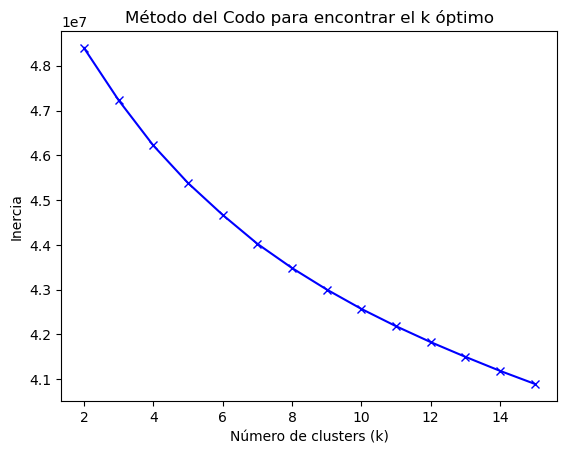

In [ ]:

inercias = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.plot(K_range, inercias, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para encontrar el k óptimo')
plt.show()